In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib import style
style.use('ggplot')
import numpy as np
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [24]:
df = pd.read_csv(r"C:\Users\usuario\Desktop\TFM\IMDB Dataset.csv")

In [25]:
df.head(3)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [26]:
df.shape

(50000, 2)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [28]:
duplicados = df.duplicated().sum()
print("Númeor de opiniones duplicadas: ", duplicados)

Númeor de opiniones duplicadas:  418


In [29]:
df = df.drop_duplicates('review')

Text(0.5, 1.0, 'Distribución de las clase')

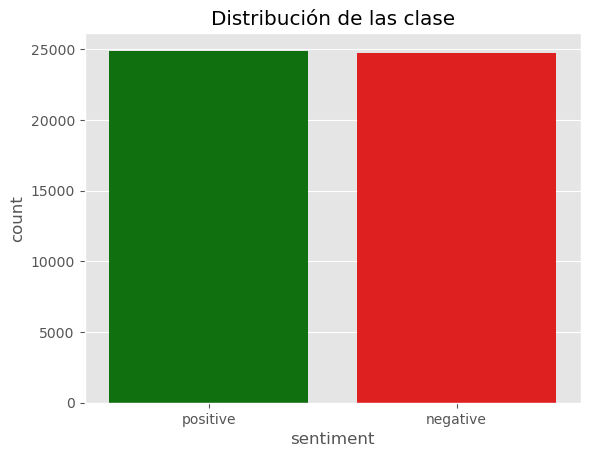

In [30]:
sns.countplot(x='sentiment', data=df,palette={'positive': 'green', 'negative': 'red'})
plt.title("Distribución de las clase")

In [31]:
def conteo_palabras(x):
    palabras= x.split()
    total = len(palabras)
    return total

In [32]:
df['conteo_palabras'] = df['review'].apply(conteo_palabras)
df.head(5)

,review,sentiment,conteo_palabras
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


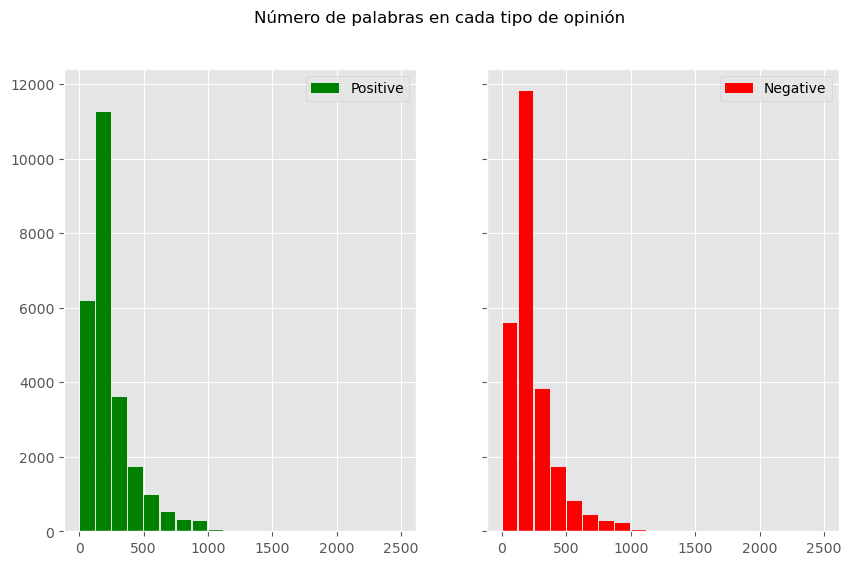

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10,6), sharex=True, sharey=True)

pos = df[df['sentiment'] == 'positive']['conteo_palabras']
neg = df[df['sentiment'] == 'negative']['conteo_palabras']

# mismos bins para ambos
bins = range(0, max(df['conteo_palabras']) + 125, 125)

ax[0].hist(pos, bins=bins, label='Positive', color='green', rwidth=0.9)
ax[0].legend(loc='upper right')

ax[1].hist(neg, bins=bins, label='Negative', color='red', rwidth=0.9)
ax[1].legend(loc='upper right')

fig.suptitle("Número de palabras en cada tipo de opinión")
plt.show()

In [33]:
df['sentiment'] = df['sentiment'].map({
    "positive": 1,
    "negative": 0
})
df_ori = df.copy()

In [34]:
def limpieza(text):
    text= text.lower() #se convierte todo a minúsculas
    text = re.sub('<br />', '', text) #se quita la etiqueta HTML
    text = re.sub(r"https\S+|www\S+|http\S+", '', text, flags = re.MULTILINE) #se suprimen URL
    text = re.sub(r'\@w+|\#', '', text) #se quita caracteres especiales
    text = re.sub(r'[^\w\s]', '', text) #se suprimen signos de puntuación
    text_tokens = word_tokenize(text) #tokenización del texto
    filtro_text = [w for w in text_tokens if not w in stop_words]
    return " ".join(filtro_text)
    

In [35]:
df.review = df['review'].apply(limpieza)

In [36]:
lemmatizer = WordNetLemmatizer()

def lemmatization(text):
    words = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmas)

df['review'] = df['review'].apply(lemmatization)

In [37]:
df['conteo_palabras'] = df['review'].apply(conteo_palabras)
df.head(5)

,review,sentiment,conteo_palabras
0,one reviewer mentioned watching 1 oz episode y...,1,168
1,wonderful little production filming technique ...,1,84
2,thought wonderful way spend time hot summer we...,1,86
3,basically there family little boy jake think t...,0,67
4,petter matteis love time money visually stunni...,1,125


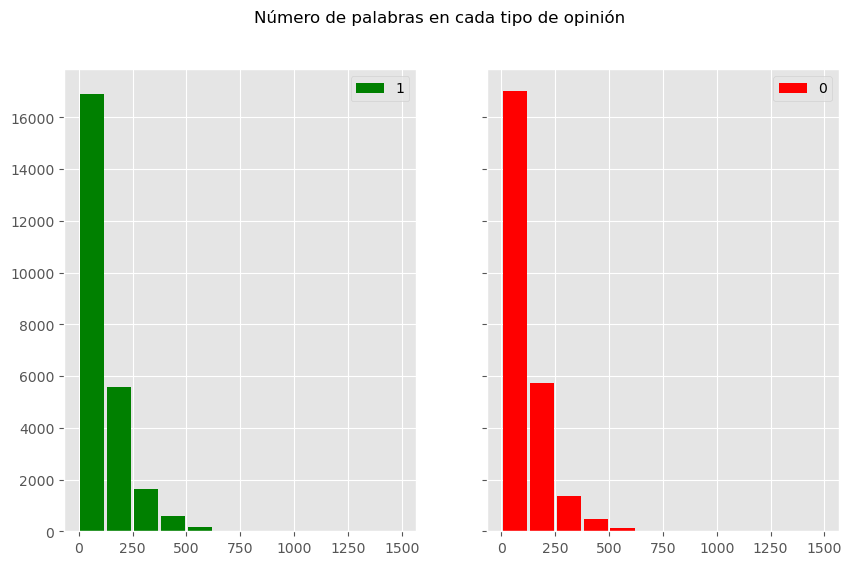

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10,6), sharex=True, sharey=True)

pos = df[df['sentiment'] == 1]['conteo_palabras']
neg = df[df['sentiment'] == 0]['conteo_palabras']

# mismos bins para ambos
bins = range(0, max(df['conteo_palabras']) + 125, 125)

ax[0].hist(pos, bins=bins, label=1, color='green', rwidth=0.9)
ax[0].legend(loc='upper right')

ax[1].hist(neg, bins=bins, label=0, color='red', rwidth=0.9)
ax[1].legend(loc='upper right')

fig.suptitle("Número de palabras en cada tipo de opinión")
plt.show()

In [18]:
from collections import Counter
pos = df[df['sentiment'] == 1]

count = Counter()
for text in pos['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('film', 47718),
 ('movie', 42896),
 ('one', 26835),
 ('like', 17476),
 ('time', 15116),
 ('good', 14353),
 ('story', 13601),
 ('character', 13565),
 ('great', 12617),
 ('see', 12477),
 ('get', 11050),
 ('well', 11031),
 ('make', 10943),
 ('really', 10641),
 ('also', 10517)]

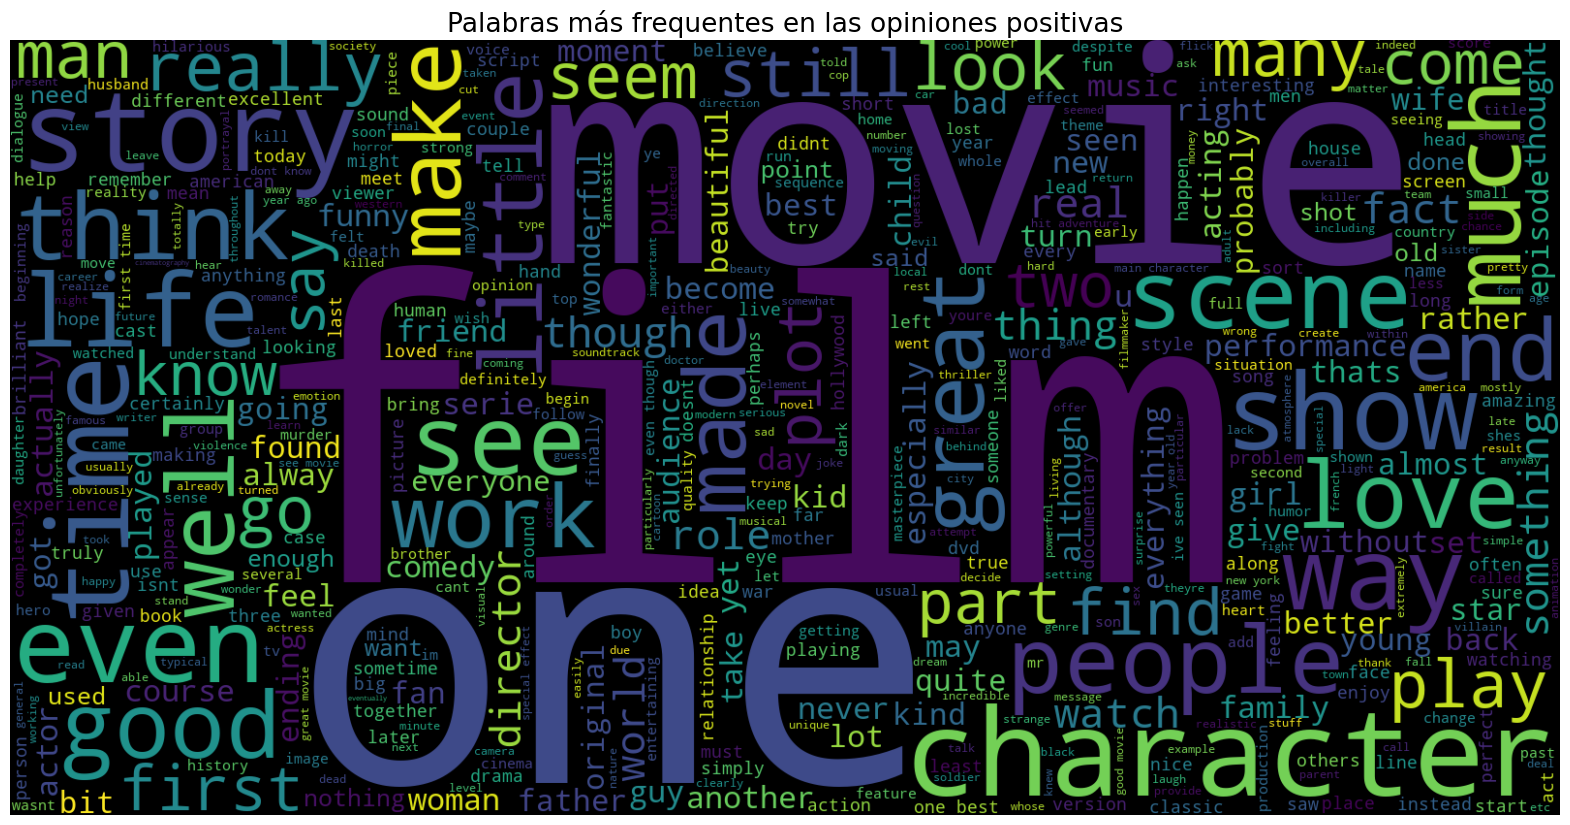

In [19]:
text = ' '.join([word for word in pos['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frequentes en las opiniones positivas', fontsize = 19)
plt.show()

In [20]:
count = Counter()
neg = df[df['sentiment'] == 0]

for text in neg['review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(15)

[('movie', 55295),
 ('film', 41415),
 ('one', 25415),
 ('like', 21972),
 ('even', 14762),
 ('good', 14043),
 ('time', 13993),
 ('bad', 13906),
 ('character', 13773),
 ('would', 13483),
 ('get', 13188),
 ('make', 12465),
 ('really', 12084),
 ('scene', 10898),
 ('see', 10804)]

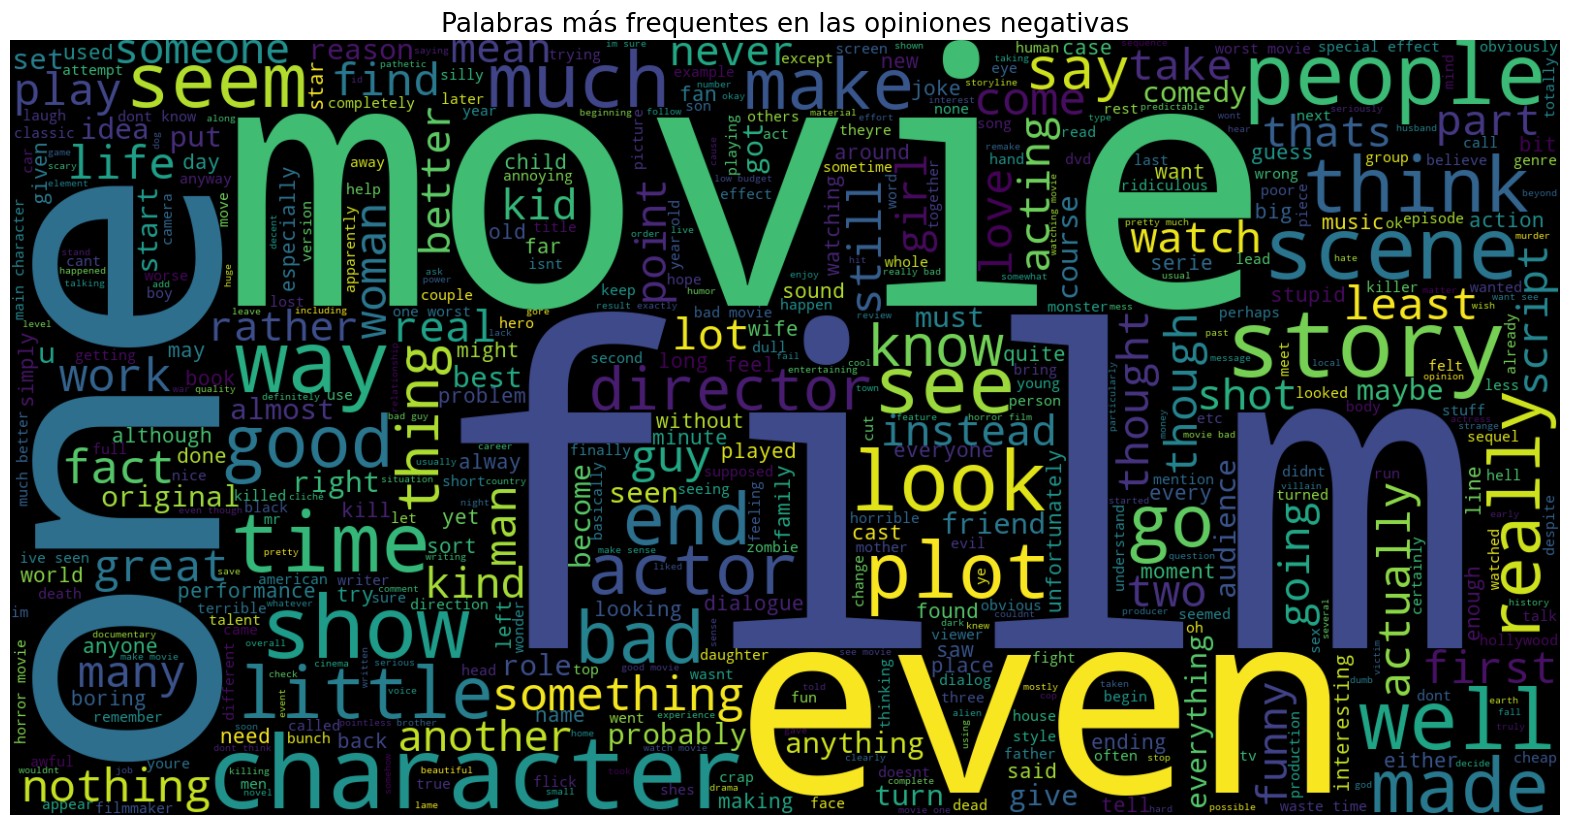

In [21]:
text = ' '.join([word for word in neg['review']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frequentes en las opiniones negativas', fontsize = 19)
plt.show()

In [38]:
x_train, x_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.3, random_state=42)

In [39]:
x_train_ori = df_ori.loc[x_train.index, "review"]
x_test_ori = df_ori.loc[x_test.index, "review"]

y_train_ori = df_ori.loc[x_train.index, "sentiment"]
y_test_ori = df_ori.loc[x_test.index, "sentiment"]

In [40]:
tf_idf = TfidfVectorizer()
x_tf_train = tf_idf.fit_transform(x_train)
x_tf_test = tf_idf.transform(x_test)

In [41]:
bag_of_words = CountVectorizer()
x_bag_train = bag_of_words.fit_transform(x_train)
x_bag_test = bag_of_words.transform(x_test)

In [42]:
bigrama_bag= CountVectorizer(ngram_range=(2,2))
x_bi_bag_train = bigrama_bag.fit_transform(x_train)
x_bi_bag_test = bigrama_bag.transform(x_test)

In [43]:
bigrama_tf = TfidfVectorizer(ngram_range=(2,2))
x_bi_tf_train = bigrama_tf.fit_transform(x_train)
x_bi_tf_test = bigrama_tf.transform(x_test)

In [28]:
rl_tf = LogisticRegression()
rl_tf.fit(x_tf_train, y_train)
rl_pred_tf = rl_tf.predict(x_tf_test)
rl_acc_tf = accuracy_score(rl_pred_tf, y_test)
print("Exactitud:", rl_acc_tf*100)

Exactitud: 89.25714285714285


In [29]:
print(confusion_matrix(y_test, rl_pred_tf))
print("\n")
print(classification_report(y_test, rl_pred_tf))

[[6509  895]
 [ 703 6768]]


              precision    recall  f1-score   support

           0       0.90      0.88      0.89      7404
           1       0.88      0.91      0.89      7471

    accuracy                           0.89     14875
   macro avg       0.89      0.89      0.89     14875
weighted avg       0.89      0.89      0.89     14875



In [30]:
rl_bag = LogisticRegression()
rl_bag.fit(x_bag_train, y_train)
rl_pred_bag = rl_bag.predict(x_bag_test)
rl_acc_bag = accuracy_score(rl_pred_bag, y_test)
print("Exactitud:",rl_acc_bag*100)

Exactitud: 88.16134453781513


In [31]:
print(confusion_matrix(y_test, rl_pred_bag))
print("\n")
print(classification_report(y_test, rl_pred_bag))

[[6488  916]
 [ 845 6626]]


              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7404
           1       0.88      0.89      0.88      7471

    accuracy                           0.88     14875
   macro avg       0.88      0.88      0.88     14875
weighted avg       0.88      0.88      0.88     14875



In [32]:
rl_bi_bag = LogisticRegression()
rl_bi_bag.fit(x_bi_bag_train, y_train)
rl_pred_bi_bag = rl_bi_bag.predict(x_bi_bag_test)
rl_acc_bi_bag = accuracy_score(rl_pred_bi_bag, y_test)
print("Exactitud:", rl_acc_tf*100)

Exactitud: 89.25714285714285


In [33]:
print(confusion_matrix(y_test, rl_pred_bi_bag))
print("\n")
print(classification_report(y_test, rl_pred_bi_bag))

[[6145 1259]
 [ 884 6587]]


              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7404
           1       0.84      0.88      0.86      7471

    accuracy                           0.86     14875
   macro avg       0.86      0.86      0.86     14875
weighted avg       0.86      0.86      0.86     14875



In [34]:
rl_bi_tf = LogisticRegression()
rl_bi_tf.fit(x_bi_tf_train, y_train)
rl_pred_bi_tf = rl_bi_tf.predict(x_bi_tf_test)
rl_acc_bi_tf = accuracy_score(rl_pred_bi_tf, y_test)
print("Exactitud:",rl_acc_bi_tf*100)

Exactitud: 85.25714285714285


In [35]:
print(confusion_matrix(y_test, rl_pred_bi_tf))
print("\n")
print(classification_report(y_test, rl_pred_bi_tf))

[[6131 1273]
 [ 920 6551]]


              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7404
           1       0.84      0.88      0.86      7471

    accuracy                           0.85     14875
   macro avg       0.85      0.85      0.85     14875
weighted avg       0.85      0.85      0.85     14875



In [36]:
err_tf = np.where(y_test != rl_pred_tf)[0]
err_bag = np.where(y_test != rl_pred_bag)[0]
err_bi_bag = np.where(y_test != rl_pred_bi_bag)[0]
err_bi_tf = np.where(y_test != rl_pred_bi_tf)[0]


In [37]:
err_bow = set(err_bag)
err_tfidf = set(err_tf)
err_bi_bag = set(err_bi_bag)
err_bi_tf = set(err_bi_tf)

bow_tfidf = len(err_bow & err_tfidf)
bow_bi_bag = len(err_bow & err_bi_bag)
bow_bi_tf = len(err_bow & err_bi_tf)
tfidf_bi_bag = len(err_tfidf & err_bi_bag)
tfidf_bi_tf = len(err_tfidf & err_bi_tf)
bi_bag_tf = len(err_bi_tf & err_bi_bag)

total_bow = len(err_bow)
total_tfidf = len(err_tfidf)
total_bi_bag = len(err_bi_bag)
total_bi_tf= len(err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        total_bow,
        bow_tfidf,
        bow_bi_bag,
        bow_bi_tf
    ],
    "TF-IDF": [
        bow_tfidf,
        total_tfidf,
        tfidf_bi_bag,
        tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        bow_bi_bag,
        tfidf_bi_bag,
        total_bi_bag,
        bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        bow_bi_tf,
        tfidf_bi_tf,
        bi_bag_tf,
        total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                        BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    1761    1212                   795             811
TF-IDF                 1212    1598                   889             942
Bigramas-Bag_of_words   795     889                  2143            1792
Bigrama-TF_IDF          811     942                  1792            2193


In [38]:
prob_bag = rl_bag.predict_proba(x_bag_test)[:, 1]
prob_tf = rl_tf.predict_proba(x_tf_test)[:, 1]
prob_bi_bag = rl_bi_bag.predict_proba(x_bi_bag_test)[:, 1]
prob_bi_tf = rl_bi_tf.predict_proba(x_bi_tf_test)[:, 1]

fallo_uni = (rl_pred_bag != y_test) & (rl_pred_tf != y_test)
acierto_bi = (rl_pred_bi_bag == y_test) & (rl_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", rl_pred_bag[idx])
    print("TF-IDF:", rl_pred_tf[idx])
    print("Bigram BoW:", rl_pred_bi_bag[idx])
    print("Bigram TF-IDF:", rl_pred_bi_tf[idx])
    print(f"BoW: {rl_pred_bag[idx]} (Prob: {prob_bag[idx]:.2%})")
    print(f"TF-IDF: {rl_pred_tf[idx]} (Prob: {prob_tf[idx]:.2%})")
    print(f"Bigram BoW: {rl_pred_bi_bag[idx]} (Prob: {prob_bi_bag[idx]:.2%})")
    print(f"Bigram TF-IDF: {rl_pred_bi_tf[idx]} (Prob: {prob_bi_tf[idx]:.2%})")
    print("------")


TEXTO:
I preface by stating I am a big fan of JJL and NOT one of Patrick. Therefore I watched this to see her performance and of course, it was excellent. I do not feel the director was adequate for the film as several very bad choices were made re: shot angles, blocking, etc. If the director was trying to give it a "realistic" feel, they failed and lost some good performances because of it. Nearly always felt that the camera was way too static, too far from intense facial reactions -- and so many times when the action depended on the intimacy of lead characters, the dialog was slow and plodding. This easily could have been resolved by cutaways or changes of camera angle. But the impression I got was that the budget was too small and only one camera was used! I also got the impression that perhaps scenes were shot multiple times and the energy coming from the actors was... used up.

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
BoW: 1 (Prob: 75.33%)
TF-IDF: 1 (P

In [39]:
fallo_bi = (rl_pred_bi_bag != y_test) & (rl_pred_bi_tf != y_test)
acierto_uni = (rl_pred_bag == y_test) & (rl_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", rl_pred_bag[idx])
    print("TF-IDF:", rl_pred_tf[idx])
    print("Bigram BoW:", rl_pred_bi_bag[idx])
    print("Bigram TF-IDF:", rl_pred_bi_tf[idx])
    print(f"BoW: {rl_pred_bag[idx]} (Prob: {prob_bag[idx]:.2%})")
    print(f"TF-IDF: {rl_pred_tf[idx]} (Prob: {prob_tf[idx]:.2%})")
    print(f"Bigram BoW: {rl_pred_bi_bag[idx]} (Prob: {prob_bi_bag[idx]:.2%})")
    print(f"Bigram TF-IDF: {rl_pred_bi_tf[idx]} (Prob: {prob_bi_tf[idx]:.2%})")
    print("------")
    print("------")

TEXTO:
This had the promise of being an interesting film. The subject matter was certainly a promising one - the excesses of the Catholic Church during the counter-reformation. However, not only was this not developed (other than a two paragraph introduction), many things were not explained - i.e. the gypsies, the Anabaptists, the inquisitors and their relationship to the one true church. Nor were the politics of the time explained, i.e. the relationship between the Catholic church and its supporters like the Holy Roman Emperor. Though these may have been apparent to an Austrian audience, the lack of explanation makes it confusing for Americans.<br /><br />But perhaps it's a good thing that they didn't emphasize the history since what they showed was pretty inaccurate anyway. Instruments of torture, bloody executions, witch and heretic burnings, big shiny swords and pretty golden reliquaries are the stars of the film. It could have just as easily been one of those Conan-type sword and 

In [40]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", rl_pred_bag[idx])
    print("TF-IDF:", rl_pred_tf[idx])
    print("Bigram BoW:", rl_pred_bi_bag[idx])
    print("Bigram TF-IDF:", rl_pred_bi_tf[idx])
    print(f"BoW: {rl_pred_bag[idx]} (Prob: {prob_bag[idx]:.2%})")
    print(f"TF-IDF: {rl_pred_tf[idx]} (Prob: {prob_tf[idx]:.2%})")
    print(f"Bigram BoW: {rl_pred_bi_bag[idx]} (Prob: {prob_bi_bag[idx]:.2%})")
    print(f"Bigram TF-IDF: {rl_pred_bi_tf[idx]} (Prob: {prob_bi_tf[idx]:.2%})")
    print("------")
    print("------")

TEXTO:
"National Treasure" (2004) is a thoroughly misguided hodge-podge of plot entanglements that borrow from nearly every cloak and dagger government conspiracy cliché that has ever been written. The film stars Nicholas Cage as Benjamin Franklin Gates (how precious is that, I ask you?); a seemingly normal fellow who, for no other reason than being of a lineage of like-minded misguided fortune hunters, decides to steal a 'national treasure' that has been hidden by the United States founding fathers. After a bit of subtext and background that plays laughably (unintentionally) like Indiana Jones meets The Patriot, the film degenerates into one misguided whimsy after another  attempting to create a 'Stanley Goodspeed' regurgitation of Nicholas Cage and launch the whole convoluted mess forward with a series of high octane, but disconnected misadventures.<br /><br />The relevancy and logic to having George Washington and his motley crew of patriots burying a king's ransom someplace on nat

In [45]:
nb_tf = MultinomialNB()
nb_tf.fit(x_tf_train, y_train)
nb_pred_tf = nb_tf.predict(x_tf_test)
nb_acc_tf = accuracy_score(nb_pred_tf, y_test)
print("Exactitud:", nb_acc_tf*100)

Exactitud: 86.32605042016806


In [43]:
print(confusion_matrix(y_test, nb_pred_tf))
print("\n")
print(classification_report(y_test, nb_pred_tf))

[[6455  949]
 [1085 6386]]


              precision    recall  f1-score   support

           0       0.86      0.87      0.86      7404
           1       0.87      0.85      0.86      7471

    accuracy                           0.86     14875
   macro avg       0.86      0.86      0.86     14875
weighted avg       0.86      0.86      0.86     14875



In [46]:
nb_bag = MultinomialNB()
nb_bag.fit(x_bag_train, y_train)
nb_pred_bag = nb_bag.predict(x_bag_test)
nb_acc_bag = accuracy_score(nb_pred_bag, y_test)
print("Exactitud:", nb_acc_bag*100)

Exactitud: 85.54621848739495


In [47]:
print(confusion_matrix(y_test, nb_pred_bag))
print("\n")
print(classification_report(y_test, nb_pred_bag))

[[6461  943]
 [1207 6264]]


              precision    recall  f1-score   support

           0       0.84      0.87      0.86      7404
           1       0.87      0.84      0.85      7471

    accuracy                           0.86     14875
   macro avg       0.86      0.86      0.86     14875
weighted avg       0.86      0.86      0.86     14875



In [48]:
nb_bi_bag = MultinomialNB()
nb_bi_bag.fit(x_bi_bag_train, y_train)
nb_pred_bi_bag = nb_bi_bag.predict(x_bi_bag_test)
nb_acc_bi_bag = accuracy_score(nb_pred_bi_bag, y_test)
print("Exactitud:", nb_acc_bi_bag*100)

Exactitud: 87.47563025210084


In [49]:
print(confusion_matrix(y_test, nb_pred_bi_bag))
print("\n")
print(classification_report(y_test, nb_pred_bi_bag))

[[6630  774]
 [1089 6382]]


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      7404
           1       0.89      0.85      0.87      7471

    accuracy                           0.87     14875
   macro avg       0.88      0.87      0.87     14875
weighted avg       0.88      0.87      0.87     14875



In [50]:
nb_bi_tf = MultinomialNB()
nb_bi_tf.fit(x_bi_tf_train, y_train)
nb_pred_bi_tf = nb_bi_tf.predict(x_bi_tf_test)
nb_acc_bi_tf = accuracy_score(nb_pred_bi_tf, y_test)
print("Exactitud:", nb_acc_bi_tf*100)

Exactitud: 87.8655462184874


In [51]:
print(confusion_matrix(y_test, nb_pred_bi_tf))
print("\n")
print(classification_report(y_test, nb_pred_bi_tf))

[[6655  749]
 [1056 6415]]


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      7404
           1       0.90      0.86      0.88      7471

    accuracy                           0.88     14875
   macro avg       0.88      0.88      0.88     14875
weighted avg       0.88      0.88      0.88     14875



In [52]:
nb_err_bag = np.where(y_test != nb_pred_bag)[0]
nb_err_bi_bag = np.where(y_test != nb_pred_bi_bag)[0]
nb_err_bi_tf = np.where(y_test != nb_pred_bi_tf)[0]
nb_err_tf = np.where(y_test != nb_pred_tf)[0]

In [53]:
nb_err_bow = set(nb_err_bag)
nb_err_tfidf = set(nb_err_tf)
nb_err_bi_bag = set(nb_err_bi_bag)
nb_err_bi_tf = set(nb_err_bi_tf)

nb_bow_tfidf = len(nb_err_bow & nb_err_tfidf)
nb_bow_bi_bag = len(nb_err_bow & nb_err_bi_bag)
nb_bow_bi_tf = len(nb_err_bow & nb_err_bi_tf)
nb_tfidf_bi_bag = len(nb_err_tfidf & nb_err_bi_bag)
nb_tfidf_bi_tf = len(nb_err_tfidf & nb_err_bi_tf)
nb_bi_bag_tf = len(nb_err_bi_tf & nb_err_bi_bag)

nb_total_bow = len(err_bow)
nb_total_tfidf = len(err_tfidf)
nb_total_bi_bag = len(err_bi_bag)
nb_total_bi_tf= len(err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        nb_total_bow,
        nb_bow_tfidf,
        nb_bow_bi_bag,
        nb_bow_bi_tf
    ],
    "TF-IDF": [
        nb_bow_tfidf,
        nb_total_tfidf,
        nb_tfidf_bi_bag,
        nb_tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        nb_bow_bi_bag,
        nb_tfidf_bi_bag,
        nb_total_bi_bag,
        nb_bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        nb_bow_bi_tf,
        nb_tfidf_bi_tf,
        nb_bi_bag_tf,
        nb_total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                        BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    1761    1849                  1170            1095
TF-IDF                 1849    1598                  1128            1068
Bigramas-Bag_of_words  1170    1128                  2143            1508
Bigrama-TF_IDF         1095    1068                  1508            2193


In [55]:
fallo_uni = (nb_pred_bag != y_test) & (nb_pred_tf != y_test)
acierto_bi = (nb_pred_bi_bag == y_test) & (nb_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", nb_pred_bag[idx])
    print("TF-IDF:", nb_pred_tf[idx])
    print("Bigram BoW:", nb_pred_bi_bag[idx])
    print("Bigram TF-IDF:", nb_pred_bi_tf[idx])
    print("------")


TEXTO:
"National Treasure" (2004) is a thoroughly misguided hodge-podge of plot entanglements that borrow from nearly every cloak and dagger government conspiracy cliché that has ever been written. The film stars Nicholas Cage as Benjamin Franklin Gates (how precious is that, I ask you?); a seemingly normal fellow who, for no other reason than being of a lineage of like-minded misguided fortune hunters, decides to steal a 'national treasure' that has been hidden by the United States founding fathers. After a bit of subtext and background that plays laughably (unintentionally) like Indiana Jones meets The Patriot, the film degenerates into one misguided whimsy after another  attempting to create a 'Stanley Goodspeed' regurgitation of Nicholas Cage and launch the whole convoluted mess forward with a series of high octane, but disconnected misadventures.<br /><br />The relevancy and logic to having George Washington and his motley crew of patriots burying a king's ransom someplace on nat

In [58]:
fallo_bi = (nb_pred_bi_bag != y_test) & (nb_pred_bi_tf != y_test)
acierto_uni = (nb_pred_bag == y_test) & (nb_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", nb_pred_bag[idx])
    print("TF-IDF:", nb_pred_tf[idx])
    print("Bigram BoW:", nb_pred_bi_bag[idx])
    print("Bigram TF-IDF:", nb_pred_bi_tf[idx])
    print("------")

TEXTO:
This had the promise of being an interesting film. The subject matter was certainly a promising one - the excesses of the Catholic Church during the counter-reformation. However, not only was this not developed (other than a two paragraph introduction), many things were not explained - i.e. the gypsies, the Anabaptists, the inquisitors and their relationship to the one true church. Nor were the politics of the time explained, i.e. the relationship between the Catholic church and its supporters like the Holy Roman Emperor. Though these may have been apparent to an Austrian audience, the lack of explanation makes it confusing for Americans.<br /><br />But perhaps it's a good thing that they didn't emphasize the history since what they showed was pretty inaccurate anyway. Instruments of torture, bloody executions, witch and heretic burnings, big shiny swords and pretty golden reliquaries are the stars of the film. It could have just as easily been one of those Conan-type sword and 

In [57]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", nb_pred_bag[idx])
    print("TF-IDF:", nb_pred_tf[idx])
    print("Bigram BoW:", nb_pred_bi_bag[idx])
    print("Bigram TF-IDF:", nb_pred_bi_tf[idx])
    print("------")

TEXTO:
The over-heated plot of "Bonjour tristesse" is taken from a juvenile first novel by Francoise Sagan, which became a best-seller, though God knows why. For teenagers wanting to get rid of a potential step-parent it may have a certain appeal. Don't be taken in by the fact that David Niven plays the playboy father and Deborah Kerr the step-mother-in- prospect. Unfortunately, too much rests on the frail shoulders of Jean Seberg. She's beautiful and easily fulfills the image of a spoiled teenager. The problem is that she can strike poses but she can't act. Anyone who saw her as Joan of Arc in Otto Preminger's St. Joan -- Seberg's first film -- knows she was incapable at 19 of carrying a film. This movie, also by Preminger, fulfills the "promise" of the first. It was her second movie; she was now 20. What was Preminger thinking? That Niven and Kerr could compensate for Seberg's lack of acting capacity? Not a chance? Seberg's character is at the center of the story and, pretty though s

In [44]:
svm_tf = LinearSVC()
svm_tf.fit(x_tf_train, y_train)
svm_pred_tf = svm_tf.predict(x_tf_test)
svm_acc_tf = accuracy_score(svm_pred_tf, y_test)
print("Exactitud:", svm_acc_tf*100)

Exactitud: 89.45210084033613


In [45]:
print(confusion_matrix(y_test, svm_pred_tf))
print("\n")
print(classification_report(y_test, svm_pred_tf))

[[6562  842]
 [ 727 6744]]


              precision    recall  f1-score   support

           0       0.90      0.89      0.89      7404
           1       0.89      0.90      0.90      7471

    accuracy                           0.89     14875
   macro avg       0.89      0.89      0.89     14875
weighted avg       0.89      0.89      0.89     14875



In [46]:
svm_bag = LinearSVC()
svm_bag.fit(x_bag_train, y_train)
svm_pred_bag = svm_bag.predict(x_bag_test)
svm_acc_bag = accuracy_score(svm_pred_bag, y_test)
print("Exactitud:", svm_acc_bag*100)

Exactitud: 86.19831932773108


In [47]:
print(confusion_matrix(y_test, svm_pred_bag))
print("\n")
print(classification_report(y_test, svm_pred_bag))

[[6340 1064]
 [ 989 6482]]


              precision    recall  f1-score   support

           0       0.87      0.86      0.86      7404
           1       0.86      0.87      0.86      7471

    accuracy                           0.86     14875
   macro avg       0.86      0.86      0.86     14875
weighted avg       0.86      0.86      0.86     14875



In [48]:
svm_bi_bag = LinearSVC()
svm_bi_bag.fit(x_bi_bag_train, y_train)
svm_pred_bi_bag = svm_bi_bag.predict(x_bi_bag_test)
svm_acc_bi_bag = accuracy_score(svm_pred_bi_bag, y_test)
print("Exactitud:", svm_acc_bi_bag*100)

Exactitud: 85.34453781512606


In [49]:
print(confusion_matrix(y_test, svm_pred_bi_bag))
print("\n")
print(classification_report(y_test, svm_pred_bi_bag))

[[6128 1276]
 [ 904 6567]]


              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7404
           1       0.84      0.88      0.86      7471

    accuracy                           0.85     14875
   macro avg       0.85      0.85      0.85     14875
weighted avg       0.85      0.85      0.85     14875



In [50]:
svm_bi_tf = LinearSVC()
svm_bi_tf.fit(x_bi_tf_train, y_train)
svm_pred_bi_tf = svm_bi_tf.predict(x_bi_tf_test)
svm_acc_bi_tf = accuracy_score(svm_pred_bi_tf, y_test)
print("Exactitud:", svm_acc_bi_tf*100)

Exactitud: 87.09915966386555


In [51]:
print(confusion_matrix(y_test, svm_pred_bi_tf))
print("\n")
print(classification_report(y_test, svm_pred_bi_tf))

[[6318 1086]
 [ 833 6638]]


              precision    recall  f1-score   support

           0       0.88      0.85      0.87      7404
           1       0.86      0.89      0.87      7471

    accuracy                           0.87     14875
   macro avg       0.87      0.87      0.87     14875
weighted avg       0.87      0.87      0.87     14875



In [52]:
svm_err_bag = np.where(y_test != svm_pred_bag)[0]
svm_err_bi_bag = np.where(y_test != svm_pred_bi_bag)[0]
svm_err_bi_tf = np.where(y_test != svm_pred_bi_tf)[0]
svm_err_tf = np.where(y_test != svm_pred_tf)[0]

In [53]:
svm_err_bow = set(svm_err_bag)
svm_err_tfidf = set(svm_err_tf)
svm_err_bi_bag = set(svm_err_bi_bag)
svm_err_bi_tf = set(svm_err_bi_tf)

svm_bow_tfidf = len(svm_err_bow & svm_err_tfidf)
svm_bow_bi_bag = len(svm_err_bow & svm_err_bi_bag)
svm_bow_bi_tf = len(svm_err_bow & svm_err_bi_tf)
svm_tfidf_bi_bag = len(svm_err_tfidf & svm_err_bi_bag)
svm_tfidf_bi_tf = len(svm_err_tfidf & svm_err_bi_tf)
svm_bi_bag_tf = len(svm_err_bi_tf & svm_err_bi_bag)

svm_total_bow = len(svm_err_bow)
svm_total_tfidf = len(svm_err_tfidf)
svm_total_bi_bag = len(svm_err_bi_bag)
svm_total_bi_tf= len(svm_err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        svm_total_bow,
        svm_bow_tfidf,
        svm_bow_bi_bag,
        svm_bow_bi_tf
    ],
    "TF-IDF": [
        svm_bow_tfidf,
        svm_total_tfidf,
        svm_tfidf_bi_bag,
        svm_tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        svm_bow_bi_bag,
        svm_tfidf_bi_bag,
        svm_total_bi_bag,
        svm_bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        svm_bow_bi_tf,
        svm_tfidf_bi_tf,
        svm_bi_bag_tf,
        svm_total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                        BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    2053    1357                   828             802
TF-IDF                 1357    1569                   775             792
Bigramas-Bag_of_words   828     775                  2180            1664
Bigrama-TF_IDF          802     792                  1664            1919


In [54]:
fallo_uni = (svm_pred_bag != y_test) & (svm_pred_tf != y_test)
acierto_bi = (svm_pred_bi_bag == y_test) & (svm_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", svm_pred_bag[idx])
    print("TF-IDF:", svm_pred_tf[idx])
    print("Bigram BoW:", svm_pred_bi_bag[idx])
    print("Bigram TF-IDF:", svm_pred_bi_tf[idx])
    print("------")


TEXTO:
I preface by stating I am a big fan of JJL and NOT one of Patrick. Therefore I watched this to see her performance and of course, it was excellent. I do not feel the director was adequate for the film as several very bad choices were made re: shot angles, blocking, etc. If the director was trying to give it a "realistic" feel, they failed and lost some good performances because of it. Nearly always felt that the camera was way too static, too far from intense facial reactions -- and so many times when the action depended on the intimacy of lead characters, the dialog was slow and plodding. This easily could have been resolved by cutaways or changes of camera angle. But the impression I got was that the budget was too small and only one camera was used! I also got the impression that perhaps scenes were shot multiple times and the energy coming from the actors was... used up.

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
... to not live in M

In [55]:
fallo_bi = (svm_pred_bi_bag != y_test) & (svm_pred_bi_tf != y_test)
acierto_uni = (svm_pred_bag == y_test) & (svm_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", svm_pred_bag[idx])
    print("TF-IDF:", svm_pred_tf[idx])
    print("Bigram BoW:", svm_pred_bi_bag[idx])
    print("Bigram TF-IDF:", svm_pred_bi_tf[idx])
    print("------")

TEXTO:
This had the promise of being an interesting film. The subject matter was certainly a promising one - the excesses of the Catholic Church during the counter-reformation. However, not only was this not developed (other than a two paragraph introduction), many things were not explained - i.e. the gypsies, the Anabaptists, the inquisitors and their relationship to the one true church. Nor were the politics of the time explained, i.e. the relationship between the Catholic church and its supporters like the Holy Roman Emperor. Though these may have been apparent to an Austrian audience, the lack of explanation makes it confusing for Americans.<br /><br />But perhaps it's a good thing that they didn't emphasize the history since what they showed was pretty inaccurate anyway. Instruments of torture, bloody executions, witch and heretic burnings, big shiny swords and pretty golden reliquaries are the stars of the film. It could have just as easily been one of those Conan-type sword and 

In [56]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", svm_pred_bag[idx])
    print("TF-IDF:", svm_pred_tf[idx])
    print("Bigram BoW:", svm_pred_bi_bag[idx])
    print("Bigram TF-IDF:", svm_pred_bi_tf[idx])
    print("------")

TEXTO:
A horror movie is being shot and things aren't going well. It's about a masked killer. The director tells off the killer in front of the cast and crew. He goes crazy and kills two people. He's killed himself and the film is never finished. Twelve years later a bunch of film students decide to try and finish it--but there's a curse. People who try and finish it are killed themselves. The students ignore that. Guess what happens next?<br /><br />The plot is old hat but this isn't bad...for what it is (a low budget slasher film). It's well-made with a young and fairly talented young cast. No one is great but no one is terrible either. It also avoids the obligatory (and needless) female nude scenes. It moves quickly, the gore is nice and bloody and the script doesn't insult your intelligence. Also Molly Ringwald is in this having the time of her life playing a bitchy faded actress.<br /><br />No great shakes but not bad at all. I give it a 7.

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0


In [28]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp.fit(x_tf_train, y_train)
mlp_pred_tf = mlp.predict(x_tf_test)
mlp_acc_tf = accuracy_score(mlp_pred_tf, y_test)
print("Exactitud:", mlp_acc_tf*100)

Iteration 1, loss = 0.51462434
Validation score: 0.890810
Iteration 2, loss = 0.23900585
Validation score: 0.900893
Iteration 3, loss = 0.13642102
Validation score: 0.902334
Iteration 4, loss = 0.08509955
Validation score: 0.899453
Iteration 5, loss = 0.05545245
Validation score: 0.895131
Iteration 6, loss = 0.03765144
Validation score: 0.893114
Iteration 7, loss = 0.02697018
Validation score: 0.889657
Iteration 8, loss = 0.02026207
Validation score: 0.888793
Iteration 9, loss = 0.01597850
Validation score: 0.885624
Iteration 10, loss = 0.01314980
Validation score: 0.888217
Iteration 11, loss = 0.01120522
Validation score: 0.886200
Iteration 12, loss = 0.00982136
Validation score: 0.885912
Iteration 13, loss = 0.00880393
Validation score: 0.885048
Iteration 14, loss = 0.00802763
Validation score: 0.884759
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Exactitud: 90.07058823529411


In [29]:
print(confusion_matrix(y_test, mlp_pred_tf))
print("\n")
print(classification_report(y_test, mlp_pred_tf))

[[6630  774]
 [ 703 6768]]


              precision    recall  f1-score   support

           0       0.90      0.90      0.90      7404
           1       0.90      0.91      0.90      7471

    accuracy                           0.90     14875
   macro avg       0.90      0.90      0.90     14875
weighted avg       0.90      0.90      0.90     14875



In [30]:
mlp_bag = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp_bag.fit(x_bag_train, y_train)
mlp_pred_bag = mlp_bag.predict(x_bag_test)
mlp_acc_bag = accuracy_score(mlp_pred_bag, y_test)
print("Exactitud:", mlp_acc_bag*100)

Iteration 1, loss = 0.34100896
Validation score: 0.889369
Iteration 2, loss = 0.12733214
Validation score: 0.883895
Iteration 3, loss = 0.06074627
Validation score: 0.880438
Iteration 4, loss = 0.03084425
Validation score: 0.876404
Iteration 5, loss = 0.01711389
Validation score: 0.872371
Iteration 6, loss = 0.01041058
Validation score: 0.871507
Iteration 7, loss = 0.00687886
Validation score: 0.870642
Iteration 8, loss = 0.00492522
Validation score: 0.870931
Iteration 9, loss = 0.00376577
Validation score: 0.870066
Iteration 10, loss = 0.00304590
Validation score: 0.866897
Iteration 11, loss = 0.00257442
Validation score: 0.866321
Iteration 12, loss = 0.00223457
Validation score: 0.865457
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Exactitud: 89.49243697478991


In [31]:
print(confusion_matrix(y_test, mlp_pred_bag))
print("\n")
print(classification_report(y_test, mlp_pred_bag))

[[6655  749]
 [ 814 6657]]


              precision    recall  f1-score   support

           0       0.89      0.90      0.89      7404
           1       0.90      0.89      0.89      7471

    accuracy                           0.89     14875
   macro avg       0.89      0.89      0.89     14875
weighted avg       0.89      0.89      0.89     14875



In [33]:
mlp_bi_bag = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp_bi_bag.fit(x_bi_bag_train, y_train)
mlp_pred_bi_bag = mlp_bi_bag.predict(x_bi_bag_test)
mlp_acc_bi_bag = accuracy_score(mlp_pred_bi_bag, y_test)
print("Exactitud:", mlp_acc_bi_bag*100)

Iteration 1, loss = 0.42116974
Validation score: 0.873523
Iteration 2, loss = 0.01546350
Validation score: 0.874100
Iteration 3, loss = 0.00578237
Validation score: 0.874388
Iteration 4, loss = 0.00418610
Validation score: 0.876693
Iteration 5, loss = 0.00343278
Validation score: 0.875540
Iteration 6, loss = 0.00299686
Validation score: 0.876116
Iteration 7, loss = 0.00267429
Validation score: 0.874964
Iteration 8, loss = 0.00246914
Validation score: 0.874964
Iteration 9, loss = 0.00231183
Validation score: 0.874676
Iteration 10, loss = 0.00218552
Validation score: 0.875828
Iteration 11, loss = 0.00207527
Validation score: 0.875252
Iteration 12, loss = 0.00198501
Validation score: 0.874388
Iteration 13, loss = 0.00188898
Validation score: 0.874388
Iteration 14, loss = 0.00180995
Validation score: 0.874676
Iteration 15, loss = 0.00173647
Validation score: 0.874964
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Exactitud: 88.10756302521008


In [34]:
print(confusion_matrix(y_test, mlp_pred_bi_bag))
print("\n")
print(classification_report(y_test, mlp_pred_bi_bag))

[[6384 1020]
 [ 749 6722]]


              precision    recall  f1-score   support

           0       0.89      0.86      0.88      7404
           1       0.87      0.90      0.88      7471

    accuracy                           0.88     14875
   macro avg       0.88      0.88      0.88     14875
weighted avg       0.88      0.88      0.88     14875



In [28]:
mlp_bi_tf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, solver='adam', early_stopping=True, verbose=True)
mlp_bi_tf.fit(x_bi_tf_train, y_train)
mlp_pred_bi_tf = mlp_bi_tf.predict(x_bi_tf_test)
mlp_acc_bi_tf = accuracy_score(mlp_pred_bi_tf, y_test)
print("Exactitud:", mlp_acc_bi_tf*100)

Iteration 1, loss = 0.62384050
Validation score: 0.853356
Iteration 2, loss = 0.16634672
Validation score: 0.885336
Iteration 3, loss = 0.02953596
Validation score: 0.887064
Iteration 4, loss = 0.01597149
Validation score: 0.887929
Iteration 5, loss = 0.01267469
Validation score: 0.887929
Iteration 6, loss = 0.01121594
Validation score: 0.888505
Iteration 7, loss = 0.01034574
Validation score: 0.889369
Iteration 8, loss = 0.00971589
Validation score: 0.890521
Iteration 9, loss = 0.00920891
Validation score: 0.891386
Iteration 10, loss = 0.00876963
Validation score: 0.890521
Iteration 11, loss = 0.00837552
Validation score: 0.890233
Iteration 12, loss = 0.00800937
Validation score: 0.889945
Iteration 13, loss = 0.00766919
Validation score: 0.891386
Iteration 14, loss = 0.00734837
Validation score: 0.891386
Iteration 15, loss = 0.00704750
Validation score: 0.890521
Iteration 16, loss = 0.00675643
Validation score: 0.889945
Iteration 17, loss = 0.00648778
Validation score: 0.892826
Iterat

In [29]:
print(confusion_matrix(y_test, mlp_pred_bi_tf))
print("\n")
print(classification_report(y_test, mlp_pred_bi_tf))

[[6445  959]
 [ 797 6674]]


              precision    recall  f1-score   support

           0       0.89      0.87      0.88      7404
           1       0.87      0.89      0.88      7471

    accuracy                           0.88     14875
   macro avg       0.88      0.88      0.88     14875
weighted avg       0.88      0.88      0.88     14875



In [38]:
np.save("predicciones_tf.npy", mlp_pred_tf)
np.save("predicciones_bag.npy", mlp_pred_bag)
np.save("predicciones_bi_bag.npy", mlp_pred_bi_bag)

In [32]:
mlp_pred_tf = np.load("predicciones_tf.npy")
mlp_pred_bag = np.load("predicciones_bag.npy")
mlp_pred_bi_bag = np.load("predicciones_bi_bag.npy")

In [38]:
np.save("predicciones_bi_tf.npy", mlp_pred_bi_tf)

In [33]:
mlp_err_bag = np.where(y_test != mlp_pred_bag)[0]
mlp_err_bi_bag = np.where(y_test != mlp_pred_bi_bag)[0]
mlp_err_bi_tf = np.where(y_test != mlp_pred_bi_tf)[0]
mlp_err_tf = np.where(y_test != mlp_pred_tf)[0]

In [34]:
mlp_err_bow = set(mlp_err_bag)
mlp_err_tfidf = set(mlp_err_tf)
mlp_err_bi_bag = set(mlp_err_bi_bag)
mlp_err_bi_tf = set(mlp_err_bi_tf)

mlp_bow_tfidf = len(mlp_err_bow & mlp_err_tfidf)
mlp_bow_bi_bag = len(mlp_err_bow & mlp_err_bi_bag)
mlp_bow_bi_tf = len(mlp_err_bow & mlp_err_bi_tf)
mlp_tfidf_bi_bag = len(mlp_err_tfidf & mlp_err_bi_bag)
mlp_tfidf_bi_tf = len(mlp_err_tfidf & mlp_err_bi_tf)
mlp_bi_bag_tf = len(mlp_err_bi_tf & mlp_err_bi_bag)

mlp_total_bow = len(mlp_err_bow)
mlp_total_tfidf = len(mlp_err_tfidf)
mlp_total_bi_bag = len(mlp_err_bi_bag)
mlp_total_bi_tf= len(mlp_err_bi_tf)

tabla = pd.DataFrame({
    "BoW": [
        mlp_total_bow,
        mlp_bow_tfidf,
        mlp_bow_bi_bag,
        mlp_bow_bi_tf
    ],
    "TF-IDF": [
        mlp_bow_tfidf,
        mlp_total_tfidf,
        mlp_tfidf_bi_bag,
        mlp_tfidf_bi_tf
    ],
    "Bigrama-Bag_of_words": [
        mlp_bow_bi_bag,
        mlp_tfidf_bi_bag,
        mlp_total_bi_bag,
        mlp_bi_bag_tf     
    ],
    "Bigrama-TF_IDF": [
        mlp_bow_bi_tf,
        mlp_tfidf_bi_tf,
        mlp_bi_bag_tf,
        mlp_total_bi_tf
        
    ]
}, index=["BoW", "TF-IDF", "Bigramas-Bag_of_words", "Bigrama-TF_IDF"])

print(tabla)

                        BoW  TF-IDF  Bigrama-Bag_of_words  Bigrama-TF_IDF
BoW                    1563    1184                   735             775
TF-IDF                 1184    1477                   745             780
Bigramas-Bag_of_words   735     745                  1769            1329
Bigrama-TF_IDF          775     780                  1329            1756


In [35]:
fallo_uni = (mlp_pred_bag != y_test) & (mlp_pred_tf != y_test)
acierto_bi = (mlp_pred_bi_bag == y_test) & (mlp_pred_bi_tf == y_test)
caso1 = fallo_uni & acierto_bi
indices_interesantes = np.where(caso1)[0]
ejemplo1 = indices_interesantes[:5]

for idx in ejemplo1:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", mlp_pred_bag[idx])
    print("TF-IDF:", mlp_pred_tf[idx])
    print("Bigram BoW:", mlp_pred_bi_bag[idx])
    print("Bigram TF-IDF:", mlp_pred_bi_tf[idx])
    print("------")


TEXTO:
I preface by stating I am a big fan of JJL and NOT one of Patrick. Therefore I watched this to see her performance and of course, it was excellent. I do not feel the director was adequate for the film as several very bad choices were made re: shot angles, blocking, etc. If the director was trying to give it a "realistic" feel, they failed and lost some good performances because of it. Nearly always felt that the camera was way too static, too far from intense facial reactions -- and so many times when the action depended on the intimacy of lead characters, the dialog was slow and plodding. This easily could have been resolved by cutaways or changes of camera angle. But the impression I got was that the budget was too small and only one camera was used! I also got the impression that perhaps scenes were shot multiple times and the energy coming from the actors was... used up.

Predicciones:
Real: 0
BoW: 1
TF-IDF: 1
Bigram BoW: 0
Bigram TF-IDF: 0
------
TEXTO:
Films about the mund

In [36]:
fallo_bi = (mlp_pred_bi_bag != y_test) & (mlp_pred_bi_tf != y_test)
acierto_uni = (mlp_pred_bag == y_test) & (mlp_pred_tf == y_test)
caso2 = fallo_bi & acierto_uni
indices_interesantes = np.where(caso2)[0]
ejemplo2 = indices_interesantes[:5]

for idx in ejemplo2:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", mlp_pred_bag[idx])
    print("TF-IDF:", mlp_pred_tf[idx])
    print("Bigram BoW:", mlp_pred_bi_bag[idx])
    print("Bigram TF-IDF:", mlp_pred_bi_tf[idx])
    print("------")

TEXTO:
His significant charisma and commanding presence are about all that keep this afloat, but Fred Williamson has done far better urban action films including many of his later, vid-released fare. The big studios' Williamson films of the early-to-mid 70's rarely had the punch of their mid-level counterparts, and this is a prime example. Clumsy action, little violence, and the PG rating is nowhere near questionable. Worth a look for Hammer completists in any case.

Predicciones:
Real: 0
BoW: 0
TF-IDF: 0
Bigram BoW: 1
Bigram TF-IDF: 1
------
TEXTO:
This had the promise of being an interesting film. The subject matter was certainly a promising one - the excesses of the Catholic Church during the counter-reformation. However, not only was this not developed (other than a two paragraph introduction), many things were not explained - i.e. the gypsies, the Anabaptists, the inquisitors and their relationship to the one true church. Nor were the politics of the time explained, i.e. the relat

In [37]:
caso3 = fallo_bi & fallo_uni
indices_interesantes = np.where(caso3)[0]
ejemplo3 = indices_interesantes[:5]

for idx in ejemplo3:
    print("TEXTO:")
    print(x_test_ori.iloc[idx])
    print("\nPredicciones:")
    print("Real:", y_test.iloc[idx])
    print("BoW:", mlp_pred_bag[idx])
    print("TF-IDF:", mlp_pred_tf[idx])
    print("Bigram BoW:", mlp_pred_bi_bag[idx])
    print("Bigram TF-IDF:", mlp_pred_bi_tf[idx])
    print("------")

TEXTO:
A horror movie is being shot and things aren't going well. It's about a masked killer. The director tells off the killer in front of the cast and crew. He goes crazy and kills two people. He's killed himself and the film is never finished. Twelve years later a bunch of film students decide to try and finish it--but there's a curse. People who try and finish it are killed themselves. The students ignore that. Guess what happens next?<br /><br />The plot is old hat but this isn't bad...for what it is (a low budget slasher film). It's well-made with a young and fairly talented young cast. No one is great but no one is terrible either. It also avoids the obligatory (and needless) female nude scenes. It moves quickly, the gore is nice and bloody and the script doesn't insult your intelligence. Also Molly Ringwald is in this having the time of her life playing a bitchy faded actress.<br /><br />No great shakes but not bad at all. I give it a 7.

Predicciones:
Real: 1
BoW: 0
TF-IDF: 0


In [97]:
tabla_bag_of_words = pd.DataFrame({
    "SVM": [
        len(svm_err_bow),
        len(svm_err_bow & nb_err_bow),
        len(svm_err_bow & mlp_err_bow),
        len(svm_err_bow & err_bow)
    ],
    "NB": [
        len(svm_err_bow & nb_err_bow),
        len(nb_err_bow),
        len(mlp_err_bow & nb_err_bow),
        len(err_bow & nb_err_bow)
    ],
    "MLP": [
        len(svm_err_bow & mlp_err_bow),
        len(nb_err_bow & mlp_err_bow),
        len(mlp_err_bow),
        len(err_bow & mlp_err_bow)
    ],
    "LR": [
        len(err_bow & svm_err_bow),
        len(err_bow & nb_err_bow),
        len(err_bow),
        len(err_bow & mlp_err_bow )
    ]
}, index=["SVM", "NB", "MLP", "LR"])

print(tabla_bag_of_words)

      SVM    NB   MLP    LR
SVM  2116   998  1144  1633
NB    998  2226  1040   990
MLP  1144  1040  1673  1868
LR   1633   990  1243  1243


In [91]:
tabla_tfidf = pd.DataFrame({
    "SVM": [
        len(svm_err_tfidf),
        len(svm_err_tfidf & svm_err_bow),
        len(svm_err_tfidf & svm_err_bi_bag),
        len(svm_err_tfidf & svm_err_bi_tf)
    ],
    "NB": [
        len(nb_err_tfidf),
        len(nb_err_tfidf & nb_err_bow),
        len(nb_err_tfidf & nb_err_bi_bag),
        len(nb_err_tfidf & nb_err_bi_tf)
    ],
    "MLP": [
        len(mlp_err_tfidf),
        len(mlp_err_tfidf & mlp_err_bow),
        len(mlp_err_tfidf & mlp_err_bi_bag),
        len(mlp_err_tfidf & mlp_err_bi_tf)
    ],
    "LR": [
        len(err_tfidf),
        len(err_tfidf & err_bow),
        len(err_tfidf & err_bi_bag),
        len(err_tfidf & err_bi_tf)
    ]
}, index=[
    "TF-IDF total",
    "TF-IDF ∩ BoW",
    "TF-IDF ∩ Bigram-BoW",
    "TF-IDF ∩ Bigram-TF-IDF"
])

print(tabla_tfidf)

                         SVM    NB   MLP    LR
TF-IDF total            1693  2105  1548  1666
TF-IDF ∩ BoW            1431  1912  1208  1278
TF-IDF ∩ Bigram-BoW      850  1191   793   921
TF-IDF ∩ Bigram-TF-IDF   846  1115   662   978


In [92]:
tabla_bi_bow = pd.DataFrame({
    "SVM": [
        len(svm_err_bi_bag),
        len(svm_err_bi_bag & svm_err_bow),
        len(svm_err_bi_bag & svm_err_tfidf),
        len(svm_err_bi_bag & svm_err_bi_tf)
    ],
    "NB": [
        len(nb_err_bi_bag),
        len(nb_err_bi_bag & nb_err_bow),
        len(nb_err_bi_bag & nb_err_tfidf),
        len(nb_err_bi_bag & nb_err_bi_tf)
    ],
    "MLP": [
        len(mlp_err_bi_bag),
        len(mlp_err_bi_bag & mlp_err_bow),
        len(mlp_err_bi_bag & mlp_err_tfidf),
        len(mlp_err_bi_bag & mlp_err_bi_tf)
    ],
    "LR": [
        len(err_bi_bag),
        len(err_bi_bag & err_bow),
        len(err_bi_bag & err_tfidf),
        len(err_bi_bag & err_bi_tf)
    ]
}, index=[
    "Bigram-BoW total",
    "Bigram-BoW ∩ BoW",
    "Bigram-BoW ∩ TF-IDF",
    "Bigram-BoW ∩ Bigram-TF-IDF"
])

print(tabla_bi_bow)

                             SVM    NB   MLP    LR
Bigram-BoW total            1886  1853  1808  2102
Bigram-BoW ∩ BoW             847  1249   802   862
Bigram-BoW ∩ TF-IDF          850  1191   793   921
Bigram-BoW ∩ Bigram-TF-IDF  1682  1501   882  1766


In [93]:
tabla_bi_tf = pd.DataFrame({
    "SVM": [
        len(svm_err_bi_tf),
        len(svm_err_bi_tf & svm_err_bow),
        len(svm_err_bi_tf & svm_err_tfidf),
        len(svm_err_bi_tf & svm_err_bi_bag)
    ],
    "NB": [
        len(nb_err_bi_tf),
        len(nb_err_bi_tf & nb_err_bow),
        len(nb_err_bi_tf & nb_err_tfidf),
        len(nb_err_bi_tf & nb_err_bi_bag)
    ],
    "MLP": [
        len(mlp_err_bi_tf),
        len(mlp_err_bi_tf & mlp_err_bow),
        len(mlp_err_bi_tf & mlp_err_tfidf),
        len(mlp_err_bi_tf & mlp_err_bi_bag)
    ],
    "LR": [
        len(err_bi_tf),
        len(err_bi_tf & err_bow),
        len(err_bi_tf & err_tfidf),
        len(err_bi_tf & err_bi_bag)
    ]
}, index=[
    "Bigram-TF total",
    "Bigram-TF ∩ BoW",
    "Bigram-TF ∩ TF-IDF",
    "Bigram-TF ∩ Bigram-BoW"
])

print(tabla_bi_tf)

                         SVM    NB   MLP    LR
Bigram-TF total         1794  1794  7513  2150
Bigram-TF ∩ BoW          838  1166   962   894
Bigram-TF ∩ TF-IDF       846  1115   662   978
Bigram-TF ∩ Bigram-BoW  1682  1501   882  1766
